# Labor Force Survey - Exploratory Data Analysis (EDA)

Created by JF Viray

This notebook is for the exploratory data analysis from the [Labor Force Survey (LFS) of April 2025](https://psada.psa.gov.ph/catalog/LFS/about). Specifically, we wish to find:
1. Find the difference in the between the youth labor force and the overall labor force
2. Composition of the Labor Force by Education Pathways
3. For each education pathway, find:
    * Unemployment
    * Employment
    * Self-Employment
    * Underemployment
    * TESDA

Below are the relevant fields from the LFS. I have also included below the description, purpose, and the codes.
| Column Name        | Description                                      | Purpose |
|--------------------|--------------------------------------------------|----------|
| PUFPWGTPRV         | Final Weight Based on Projection                | To get the estimated number (weighted estimate) of each sample |
| PUFC05_AGE          | Age as of Last Birthday                         | To get the age of the participant|
| PUFNEWEMPSTAT      | New Employment Criteria (Jul 05, 2005)          | To determine employment status |
| PUFC20_PWMORE      | Want More Hours of Work                         | To determine if underemployed |
| PUFC23_PCLASS      | Class of Worker (Primary Occupation)            | To classify worker type |
| PUFC07_GRADE       | Highest Grade Completed                         | To determine schooling level |
| PUFC09_GRADTECH    | Graduate of technical/vocational course         | To determine if TESDA graduate or not |
| PUFC25_PBASIC      | Basic Pay per Day from the Primary Occupation   | To determine the wage |

1. PUFPWGTPRV - Final Weight Based on Projection
This is in integer.

2. PUFC05_AGE - Age as of Last Birthday
This is in integer 

3. PUFNEWEMPSTAT — Employment Status

| Code | Description            |
| ---- | ---------------------- |
| 1    | Employed               |
| 2    | Unemployed             |
| 3    | Not in the Labor Force |


4. PUFC20_PWMORE — Want More Hours of Work

| Code | Description |
| ---- | ----------- |
| 1    | Yes         |
| 2    | No          |

5. PUFC23_PCLASS — Class of Worker (Primary Occupation)

| Code | Description                         |
| ---- | ----------------------------------- |
| 0    | Private Household                   |
| 1    | Private Establishment               |
| 2    | Government / Government Corporation |
| 3    | Self Employed                       |
| 4    | Employer                            |
| 5    | With Pay (Family-owned Business)    |
| 6    | Without Pay (Family-owned Business) |

6. PUFC07_GRADE — Highest Grade Completed

| Code Range    | Description                      |
| ------------- | -------------------------------- |
| 0 – 2000      | No Grade Completed               |
| 10004 – 10015 | Elementary Undergraduate         |
| 10018         | Elementary Graduate              |
| 24004 – 24013 | Junior High School Undergraduate |
| 24014 – 24015 | Junior High School Completed     |
| 34011 – 35011 | Senior High School Undergraduate |
| 34013 – 35013 | Senior High School Graduate      |
| 40001 – 50003 | Post Secondary Undergraduate     |
| 40011 – 59999 | Post Secondary Graduate          |
| 60001 – 60006 | College Undergraduate            |
| 60000 – 89999 | College Graduate                 |


7. PUFC09_GRADTECH — Graduate of Technical/Vocational Course

| Code | Description |
| ---- | ----------- |
| 1    | Yes         |
| 2    | No          |


8. PUFC25_PBASIC - Basic Pay per Day (Primary Occupation)
This is already in integers. 

# I. Cleaning the Data

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set the font
from matplotlib import font_manager as fm
fpath = "Microsoft Aptos Fonts/Aptos.ttf"
prop = fm.FontProperties(fname=fpath)
#plt.rcParams['font.family'] = 'Aptos'

from matplotlib.ticker import FuncFormatter

In [78]:
# Open and combine the January and April files
relevant_cols = ['PUFPWGTPRV', # Final Weight Based on Projection
                 'PUFC05_AGE', # Age
                 'PUFNEWEMPSTAT', # Employed (1), Unemployed (2), Not in the Labor Force (3)
                 'PUFC20_PWMORE', # Underemployed (1), NOT underemployed (2)
                 'PUFC23_PCLASS', # Self-Employed (3)
                 'PUFC07_GRADE', # Look at the code
                 'PUFC09_GRADTECH', # Went through TESDA (1), Did NOT go through TESDA (2)
                 'PUFC25_PBASIC', # Pay per Day
                 'PUFC31_FLWRK', # First time looking for work (1), no (2)
]

filepath = 'data/PHL-PSA-LFS-2025-01-PUF/LFS PUF January 2025.CSV'
jan_df = pd.read_csv(filepath)

filepath = 'data/PHL-PSA-LFS-2025-04-PUF/LFS PUF April 2025.CSV'
apr_df = pd.read_csv(filepath)
apr_df = apr_df[relevant_cols].replace(' ', np.nan)
apr_df = apr_df[relevant_cols].replace('     ', np.nan)
#apr_df.dropna(inplace=True)

# combined_df = pd.concat([jan_df, apr_df])
# combined_df = combined_df[relevant_cols].replace(' ', np.nan)

In [79]:
# We don't consider the age here. We only consider the age for the youth_labor_force.ipynb
is_lf = (apr_df['PUFNEWEMPSTAT'] == '1') | (apr_df['PUFNEWEMPSTAT'] == '2')
lf_df = apr_df[is_lf].copy()

We convert the code in the PUFC07_GRADE to something actually understandable.

In [80]:
# Education code ranges
education_ranges = {
    "No grade completed": [(0, 1000), (2000, 2000)],
    "Elementary Undergraduate": [(10011, 10015), (10004, 10006)],
    "Elementary Graduate": [(10018, 10018)],
    "Junior High School Undergraduate": [(24011, 24013), (24004, 24006)],
    "Junior High School Graduate": [(24014, 24015)],
    "Senior High School Undergraduate": [(34011, 34011), (34021, 34021), (34031, 34031), (35011, 35011)],
    "Senior High School Graduate": [(34013, 34013), (34023, 34023), (34033, 34033), (35013, 35013)],
    "Post Secondary Undergraduate": [(40001, 40003), (50001, 50003)],
    "Post Secondary Graduate": [(40011, 49999), (50011, 59999)],
    "College Undergraduate": [(60001, 60006)],
    "College Graduate": [(60000, 60000), (60011, 69999), (70000, 79999), (80000, 89999)]
}

def classify_education(code):
    """Classify the code to what grade it was completed"""
    for level, ranges in education_ranges.items():
        for lower, upper in ranges:
            if lower <= code <= upper:
                return level
    return "Unknown"

# Mapping to simplified education levels: Undergraduate vs Graduate
grade_map = {
    "Junior High School Graduate": "Junior High School",
    "College Graduate": "Higher Education Institution",
    "Elementary Graduate":"Elementary",
    "Elementary Undergraduate":"No grade completed",
    "Junior High School Undergraduate":"Elementary",
    "College Undergraduate":"Senior High School",
    "Post Secondary Graduate":"Higher Education Institution",
    "Senior High School Graduate":"Senior High School",
    "No grade completed": "No grade completed",
    "Senior High School Undergraduate": "Junior High School",
    "Post Secondary Undergraduate":"Senior High School"
}

# Finally get the grade and set it as categorical
lf_df.loc[:, 'Grade'] = lf_df['PUFC07_GRADE'].astype(int).map(classify_education).map(grade_map)
grade_order = [
    "No grade completed",
    "Elementary",
    "Junior High School",
    "Senior High School",
    "Higher Education Institution"
]

# Convert the 'Grade' column to a categorical type with ordering
lf_df['Grade'] = pd.Categorical(
    lf_df['Grade'],
    categories=grade_order,
    ordered=True
)

To make sure that all of the EDA below will be correct, I checked with LFS Summary Statistics (where the numbers are stated in the thousands). The code has to say that there are around 50,735,000 people in the labor force; 48,672,000 currently employed; unemployment rate of 4.0675%

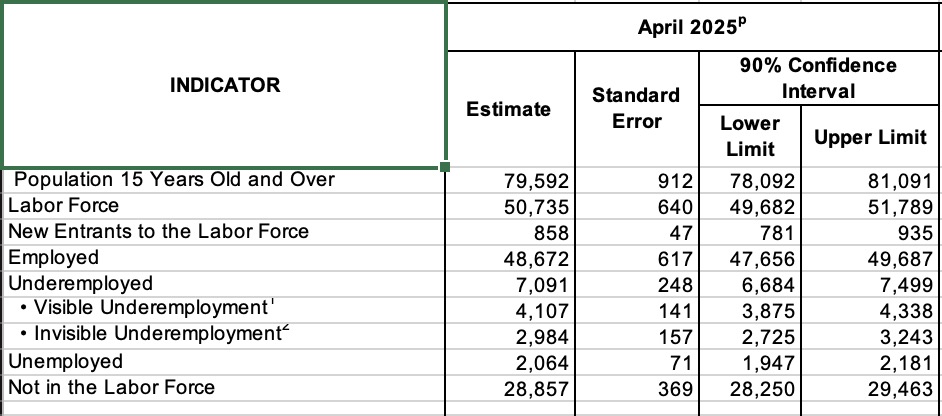 
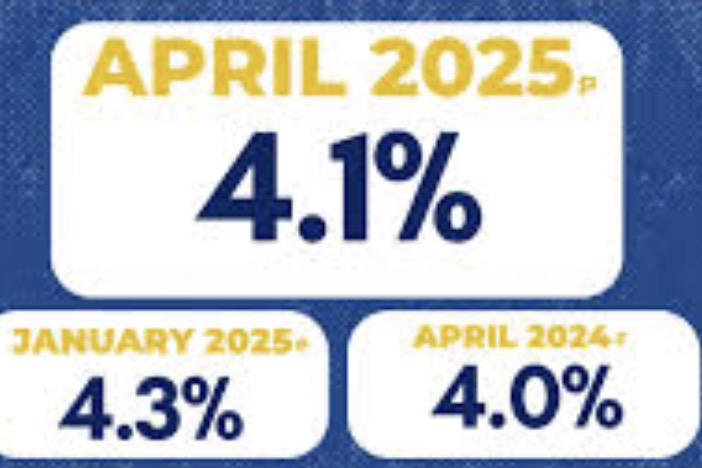

In [93]:
labor_force = lf_df['PUFPWGTPRV'].sum()
print(f"In April 2025, there were {int(labor_force)} people in the labor force.")

employed = int(lf_df[lf_df['PUFNEWEMPSTAT'] == '1']['PUFPWGTPRV'].sum())
print(f"In April 2025, there were {int(employed)} people in the labor force.")

unemployment_rate = 1 - employed / labor_force
print(f"In April 2025, the unemployment rate was {unemployment_rate *100:2f}%")

In April 2025, there were 50735293 people in the labor force.
In April 2025, there were 48671648 people in the labor force.
In April 2025, the unemployment rate was 4.067475%


# II. Composition of the Labor Force by Education Pathways

In [96]:
lf_df.groupby('Grade')['PUFPWGTPRV'].sum()

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/595340296.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lf_df.groupby('Grade')['PUFPWGTPRV'].sum()


Grade
No grade completed              5.254409e+06
Elementary                      1.036713e+07
Junior High School              1.607618e+07
Senior High School              6.629645e+06
Higher Education Institution    1.240794e+07
Name: PUFPWGTPRV, dtype: float64

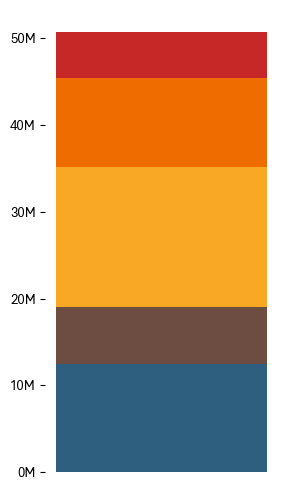

In [105]:
lf_education = lf_df.groupby('Grade', observed=False)['PUFPWGTPRV'].sum()

colors = [
    "#C62828",  # deep red
    "#EF6C00",  # orange
    "#F9A825",  # golden
    "#6D4C41",  # brown
    "#2E5F7F"   # muted blue-gray
]

fig, ax = plt.subplots(figsize=(3, 6))
bottom = 0
for (category, value), color in zip(lf_education[::-1].items(), colors[::-1]):
    plt.bar("Young Workforce", value, bottom=bottom, color=color, label=category)
    bottom += value

# Remove the spines
for spine in ['top', 'right', 'bottom', 'left']:
    plt.gca().spines[spine].set_visible(False)

# Clean the x and y axis
for tick in ax.get_yticklabels():
    tick.set_fontproperties(prop)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))

ax.set_xticks([])
#plt.legend()
plt.show()

In [106]:
lf_education

Grade
No grade completed              5.254409e+06
Elementary                      1.036713e+07
Junior High School              1.607618e+07
Senior High School              6.629645e+06
Higher Education Institution    1.240794e+07
Name: PUFPWGTPRV, dtype: float64

In [107]:
lf_education / lf_education.sum()

Grade
No grade completed              0.103565
Elementary                      0.204338
Junior High School              0.316864
Senior High School              0.130671
Higher Education Institution    0.244562
Name: PUFPWGTPRV, dtype: float64

# II. Unemployment, Employment, Self-Employment, Underemployment, TESDA Rate of the Labor Force by Education Pathways

In [108]:
# Unemployment AND Employment
employment_grouped = lf_df.groupby(['Grade', 'PUFNEWEMPSTAT'])['PUFPWGTPRV'].sum()


# Normalize per grade
employment_grouped_percent = employment_grouped.reset_index()
employment_grouped_percent.loc[:, 'Total'] = employment_grouped_percent.groupby('Grade')['PUFPWGTPRV'].transform('sum')
employment_grouped_percent.loc[:, 'Percent'] = employment_grouped_percent['PUFPWGTPRV'] / employment_grouped_percent['Total']
employment_grouped_percent

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/3816489538.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employment_grouped = lf_df.groupby(['Grade', 'PUFNEWEMPSTAT'])['PUFPWGTPRV'].sum()
/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/3816489538.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employment_grouped_percent.loc[:, 'Total'] = employment_grouped_percent.groupby('Grade')['PUFPWGTPRV'].transform('sum')


,Grade,PUFNEWEMPSTAT,PUFPWGTPRV,Total,Percent
0,No grade completed,1,5.170955e+06,5.254409e+06,0.984117
1,No grade completed,2,8.345377e+04,5.254409e+06,0.015883
2,Elementary,1,1.007389e+07,1.036713e+07,0.971714
3,Elementary,2,2.932395e+05,1.036713e+07,0.028286
4,Junior High School,1,1.554731e+07,1.607618e+07,0.967103
5,Junior High School,2,5.288627e+05,1.607618e+07,0.032897
6,Senior High School,1,6.173003e+06,6.629645e+06,0.931121
7,Senior High School,2,4.566419e+05,6.629645e+06,0.068879
8,Higher Education Institution,1,1.170649e+07,1.240794e+07,0.943468
9,Higher Education Institution,2,7.014473e+05,1.240794e+07,0.056532


In [109]:
lf_df.groupby('PUFC23_PCLASS')['PUFPWGTPRV'].sum()

PUFC23_PCLASS
0    2.045802e+06
1    2.401430e+07
2    4.607916e+06
3    1.362348e+07
4    9.688884e+05
5    8.736171e+04
6    3.323904e+06
Name: PUFPWGTPRV, dtype: float64

In [110]:
# Self-Employment
type_grouped = lf_df.groupby(['Grade', 'PUFC23_PCLASS'])['PUFPWGTPRV'].sum().reset_index()
type_grouped.loc[:, 'Total'] = type_grouped.groupby('Grade')['PUFPWGTPRV'].transform('sum')
type_grouped.loc[:, 'Percent'] = type_grouped['PUFPWGTPRV'] / type_grouped['Total']
type_grouped[type_grouped['PUFC23_PCLASS'] == '3']

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/236936898.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_grouped = lf_df.groupby(['Grade', 'PUFC23_PCLASS'])['PUFPWGTPRV'].sum().reset_index()
/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/236936898.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_grouped.loc[:, 'Total'] = type_grouped.groupby('Grade')['PUFPWGTPRV'].transform('sum')


,Grade,PUFC23_PCLASS,PUFPWGTPRV,Total,Percent
3,No grade completed,3,2.338851e+06,5.170955e+06,0.452305
10,Elementary,3,3.775906e+06,1.007389e+07,0.374821
17,Junior High School,3,4.568142e+06,1.554731e+07,0.293822
24,Senior High School,3,1.322872e+06,6.173003e+06,0.214300
31,Higher Education Institution,3,1.617710e+06,1.170649e+07,0.138189


In [111]:
# UnderEmployment
under_grouped = lf_df.groupby(['Grade', 'PUFC20_PWMORE'])['PUFPWGTPRV'].sum().reset_index()
under_grouped.loc[:, 'Total'] = under_grouped.groupby('Grade')['PUFPWGTPRV'].transform('sum')
under_grouped.loc[:, 'Percent'] = under_grouped['PUFPWGTPRV'] / under_grouped['Total']
under_grouped[under_grouped['PUFC20_PWMORE'] == '1'] # 1 means underemployed

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/1399610698.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  under_grouped = lf_df.groupby(['Grade', 'PUFC20_PWMORE'])['PUFPWGTPRV'].sum().reset_index()
/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/1399610698.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  under_grouped.loc[:, 'Total'] = under_grouped.groupby('Grade')['PUFPWGTPRV'].transform('sum')


,Grade,PUFC20_PWMORE,PUFPWGTPRV,Total,Percent
0,No grade completed,1,9.706979e+05,5.170955e+06,0.187721
2,Elementary,1,1.760277e+06,1.007389e+07,0.174737
4,Junior High School,1,2.331598e+06,1.554731e+07,0.149968
6,Senior High School,1,8.444569e+05,6.173003e+06,0.136798
8,Higher Education Institution,1,1.184073e+06,1.170649e+07,0.101147


In [112]:
# TESDA (I will most likely not include this)
is_TESDA = lf_df['PUFC09_GRADTECH'] == '1' # 1 means they went through TESDA
tesda_df = lf_df[is_TESDA]


# UnderEmployment
under_grouped = lf_df.groupby(['Grade', 'PUFC09_GRADTECH'])['PUFPWGTPRV'].sum().reset_index()
under_grouped.loc[:, 'Total'] = under_grouped.groupby('Grade')['PUFPWGTPRV'].transform('sum')
under_grouped.loc[:, 'Percent'] = under_grouped['PUFPWGTPRV'] / under_grouped['Total']
under_grouped[under_grouped['PUFC09_GRADTECH'] == '1'] # 1 means underemployed

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/1439643296.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  under_grouped = lf_df.groupby(['Grade', 'PUFC09_GRADTECH'])['PUFPWGTPRV'].sum().reset_index()
/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/1439643296.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  under_grouped.loc[:, 'Total'] = under_grouped.groupby('Grade')['PUFPWGTPRV'].transform('sum')


,Grade,PUFC09_GRADTECH,PUFPWGTPRV,Total,Percent
0,No grade completed,1,18919.6154,5.254409e+06,0.003601
2,Elementary,1,89214.9896,1.036713e+07,0.008606
4,Junior High School,1,863033.2966,1.607618e+07,0.053684
6,Senior High School,1,244904.8313,6.629645e+06,0.036941
8,Higher Education Institution,1,709440.9821,1.240794e+07,0.057176


# III. Pay per Day

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/3432934394.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usd_paid = paid_df.groupby('Grade')['PUFC25_PBASIC'].median()[::-1] * usd_to_php


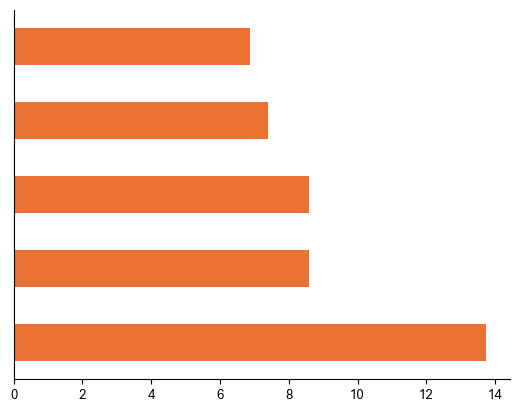

In [115]:
paid_df = lf_df.dropna(subset='PUFC25_PBASIC').copy()
paid_df.loc[:, 'PUFC25_PBASIC'] = paid_df['PUFC25_PBASIC'].astype(int)
usd_to_php = 1 / 58.23
usd_paid = paid_df.groupby('Grade')['PUFC25_PBASIC'].median()[::-1] * usd_to_php


ax = usd_paid.plot(kind='barh', color='#EA7131')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Clean the x and y axis
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)

plt.yticks([])
plt.ylabel('')

plt.show()

In [91]:
usd_paid

Grade
No grade completed               6.869311
Elementary                        7.38451
Junior High School               8.586639
Senior High School               8.586639
Higher Education Institution    13.738623
Name: PUFC25_PBASIC, dtype: object

# IV. First Time Looking For Work

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_9132/2703390822.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_worker_df.groupby('Grade')['PUFPWGTPRV'].sum().sort_values().plot(kind='barh', color='#EA7131')


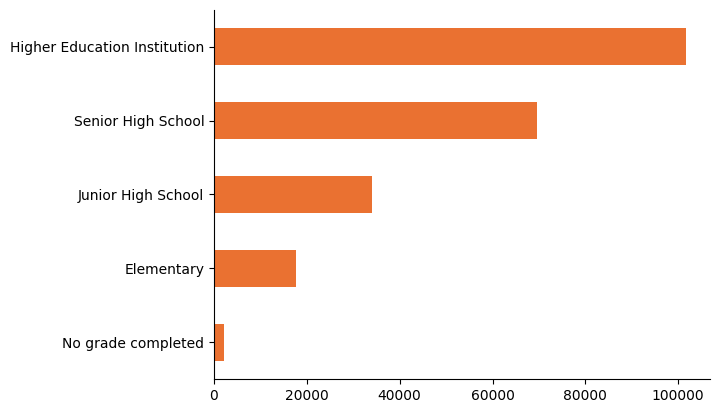

In [92]:
is_first_time = lf_df['PUFC31_FLWRK'] == '1'
new_worker_df = lf_df[is_first_time]

new_worker_df.groupby('Grade')['PUFPWGTPRV'].sum().sort_values().plot(kind='barh', color='#EA7131')

plt.ylabel('')
plt.xlabel('')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)